In [6]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [11]:
import os
print(os.getcwd())


C:\Users\poova\Machine Learning\crop


In [16]:
# 1. Load the data
df = pd.read_csv(r"C:\Users\poova\Machine Learning\crop_production.csv")
df


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0


In [17]:
df.shape

(246091, 7)

In [18]:
df.dtypes

State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

In [20]:
# import pandas as pd
# from sklearn.linear_model import LinearRegression

# # 1. Load the data
# df = pd.read_csv(r"crop_production.csv")

# # 2. Filter for just 'Rice' and remove missing data
# df_rice = df[df['Crop'].str.strip() == 'Rice'].dropna(subset=['Area', 'Production'])

# # 3. Define the X (Input) and y (Output)
# X = df_rice[['Area']]
# y = df_rice['Production']

# # 4. Create and train the model!
# model = LinearRegression()
# model.fit(X, y)

# # 5. Make a prediction! (e.g., How much rice will 50,000 hectares produce?)
# prediction = model.predict([[50000]])
# print(f"Predicted production: {prediction[0]} tonnes")

In [21]:
df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [27]:
df['Production'].fillna(df['Production'].mean(), inplace=True)
print(df)

                         State_Name District_Name  Crop_Year       Season  \
0       Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1       Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
2       Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
3       Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
4       Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
...                             ...           ...        ...          ...   
246086                  West Bengal       PURULIA       2014  Summer        
246087                  West Bengal       PURULIA       2014  Summer        
246088                  West Bengal       PURULIA       2014  Whole Year    
246089                  West Bengal       PURULIA       2014  Winter        
246090                  West Bengal       PURULIA       2014  Winter        

                       Crop      Area  Production  
0                  Arec

In [28]:
df.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

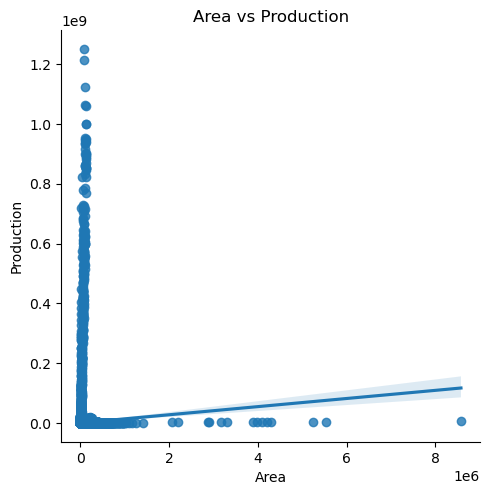

In [29]:
sns.lmplot(x='Area',y='Production',data=df)
plt.title('Area vs Production')
plt.show()

In [34]:
x=df[["Area","Crop"]]
x

,Area,Crop
0,1254.0,Arecanut
1,2.0,Other Kharif pulses
2,102.0,Rice
3,176.0,Banana
4,720.0,Cashewnut
...,...,...
246086,306.0,Rice
246087,627.0,Sesamum
246088,324.0,Sugarcane
246089,279151.0,Rice


In [36]:
y=df['Production']
y

0           2000.0
1              1.0
2            321.0
3            641.0
4            165.0
            ...   
246086       801.0
246087       463.0
246088     16250.0
246089    597899.0
246090        88.0
Name: Production, Length: 246091, dtype: float64

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [49]:
# Convert categorical 'Crop' into numeric using One-Hot Encoding
x = pd.get_dummies(x, columns=['Crop'], drop_first=True)

In [50]:
# Ensure target is numeric (in case of accidental strings)
y = pd.to_numeric(y, errors='coerce')

In [51]:
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
y_pred=model.predict(x_test)
y_pred

array([ -10951.90015205,     641.60208889,  -28136.03180175, ...,
        557817.12232217, -207155.03618872, -107894.59692349],
      shape=(49219,))

In [60]:
# Evaluation
print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)
print("R² Score:", model.score(x_test, y_test))

Intercept: -41.77994652278721
R² Score: 0.09030156809802503


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)          # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)           # Mean Squared Error
rmse = np.sqrt(mse)                                # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)                      # R² Score

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Absolute Error (MAE): 913823.0363551867
Mean Squared Error (MSE): 145155546248456.7
Root Mean Squared Error (RMSE): 12048051.554025518
R² Score: 0.09030156809802503


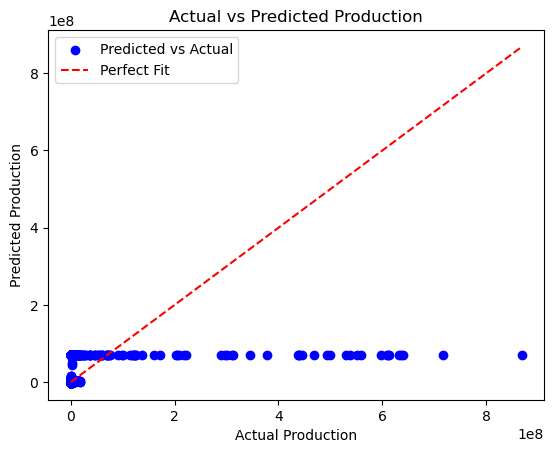

In [62]:
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')

# Add a reference line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Fit')

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Production")
plt.legend()
plt.show()


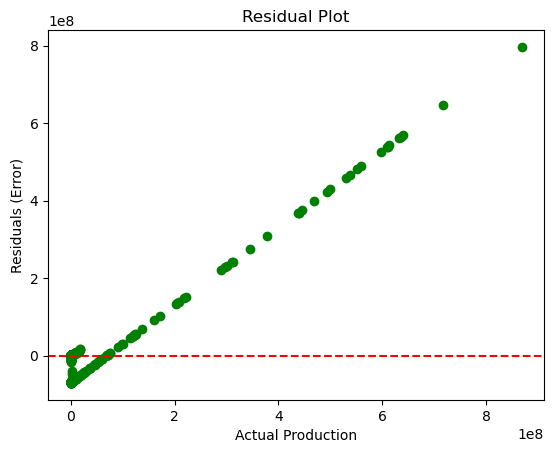

In [63]:
plt.scatter(y_test, y_test - y_pred, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Actual Production")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()


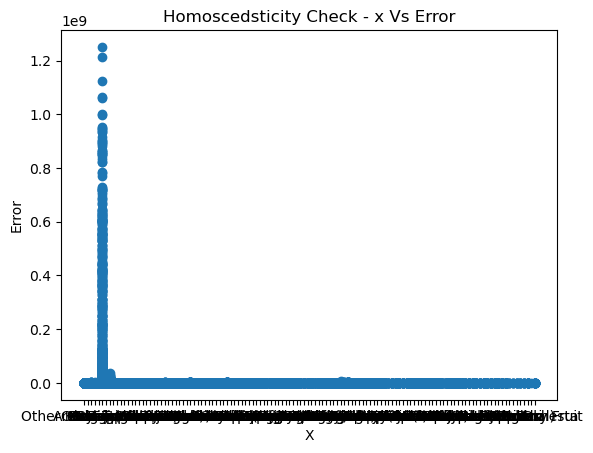

In [57]:
plt.scatter(x = df['Crop'], y=df['Production'])
plt.title('Homoscedsticity Check - x Vs Error')
plt.xlabel('X')
plt.ylabel('Error')
plt.show()